# Regression Trees

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import  StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import random

## loading dataset

In [2]:
df = pd.read_csv('diamonds.csv')
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Visualize the distributions


d:\Users\Pezhman\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 800x600 with 0 Axes>

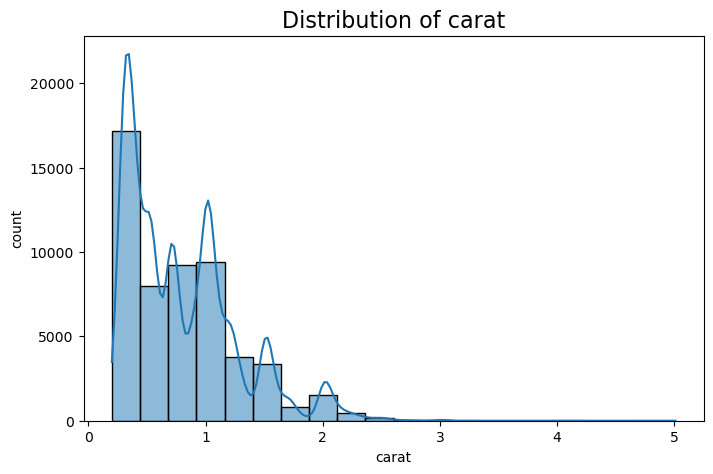

d:\Users\Pezhman\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


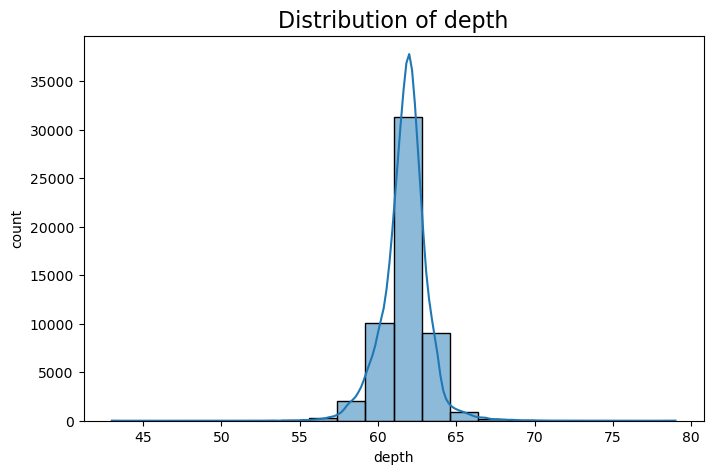

d:\Users\Pezhman\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


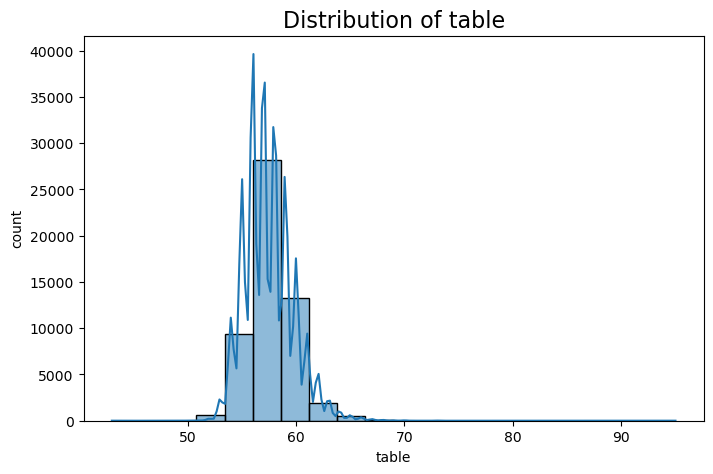

d:\Users\Pezhman\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


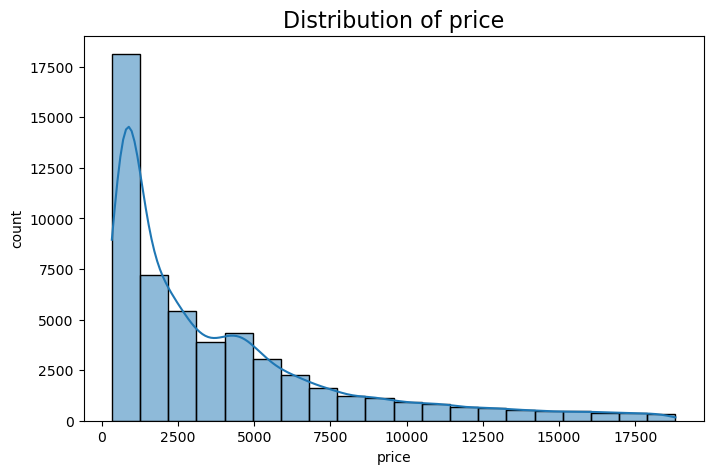

d:\Users\Pezhman\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


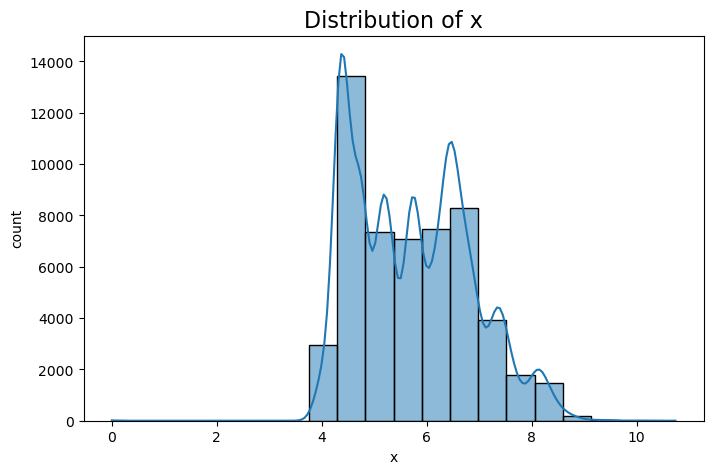

d:\Users\Pezhman\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


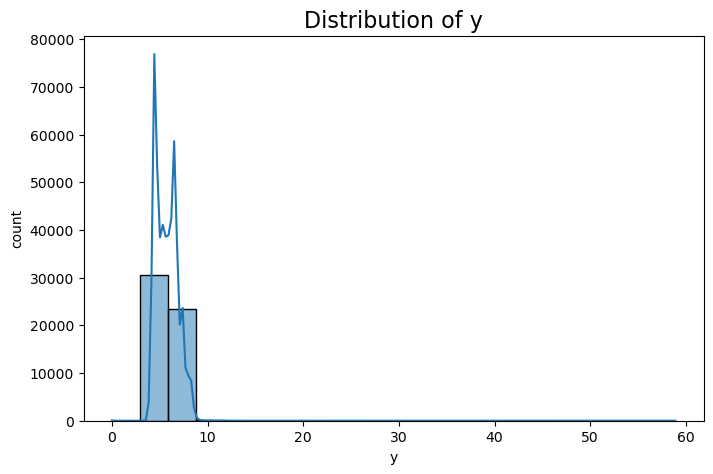

d:\Users\Pezhman\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


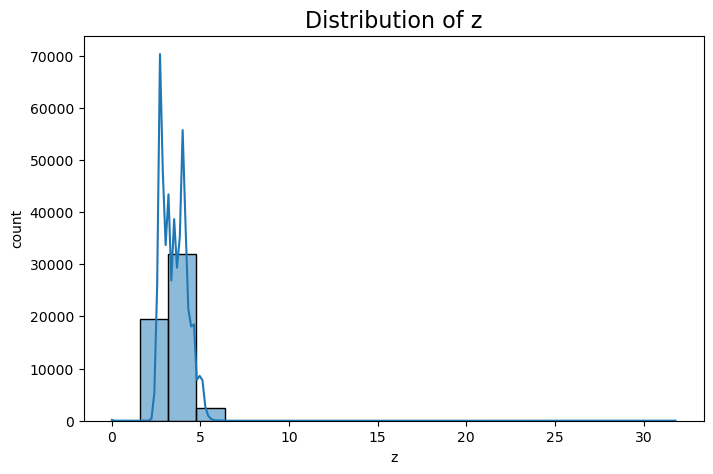

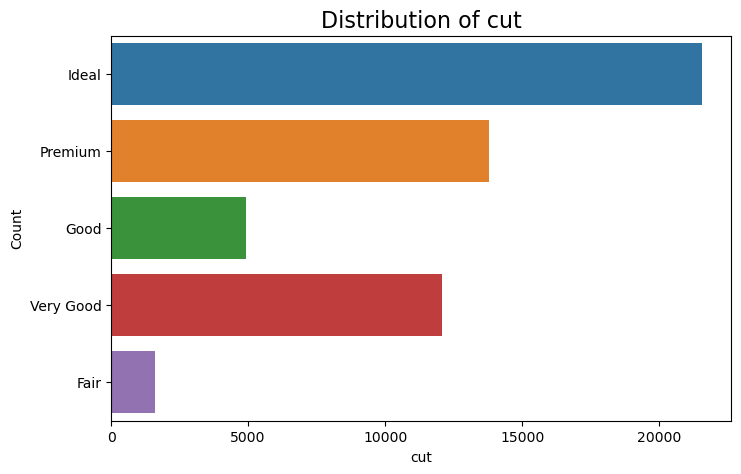

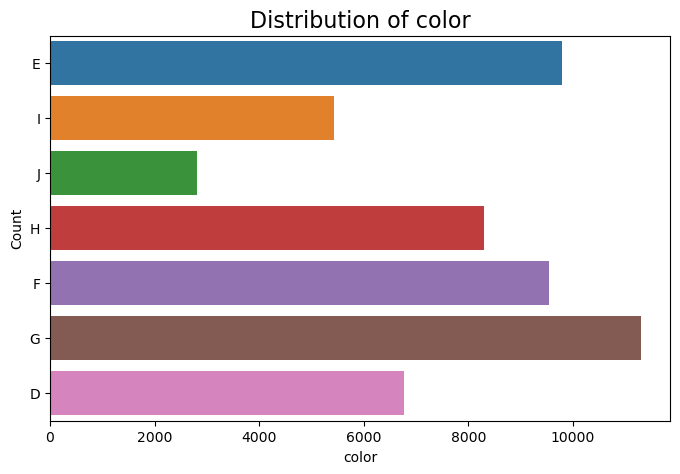

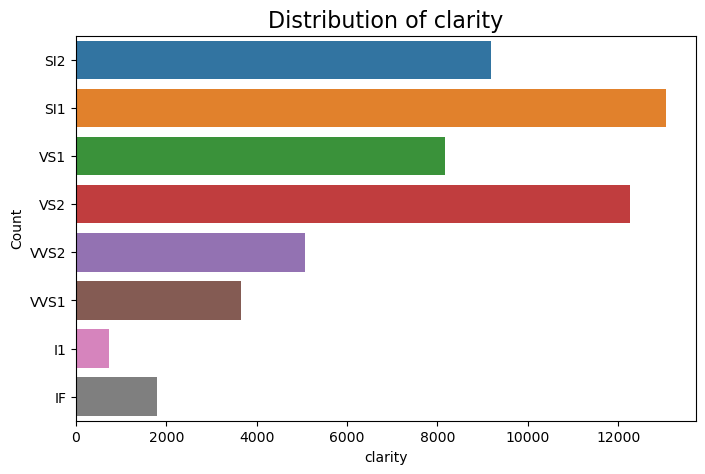

<Figure size 800x600 with 0 Axes>

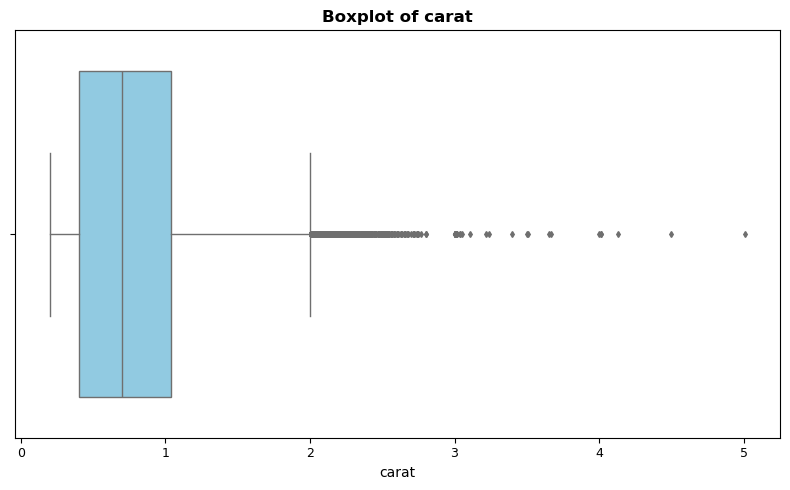

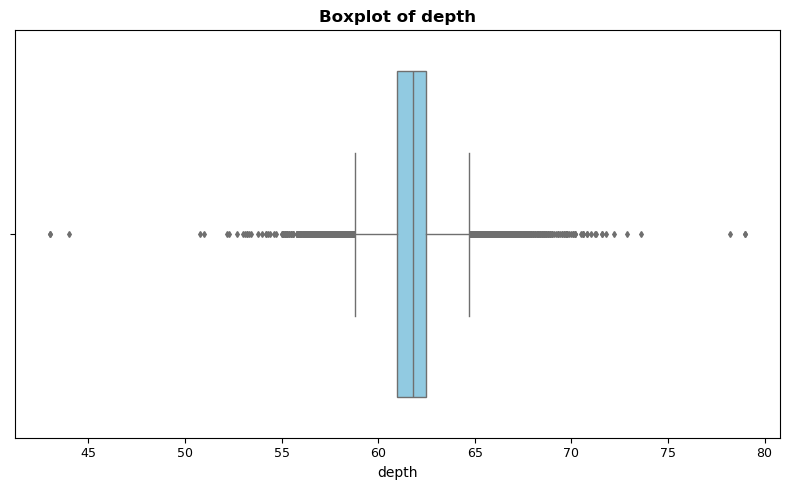

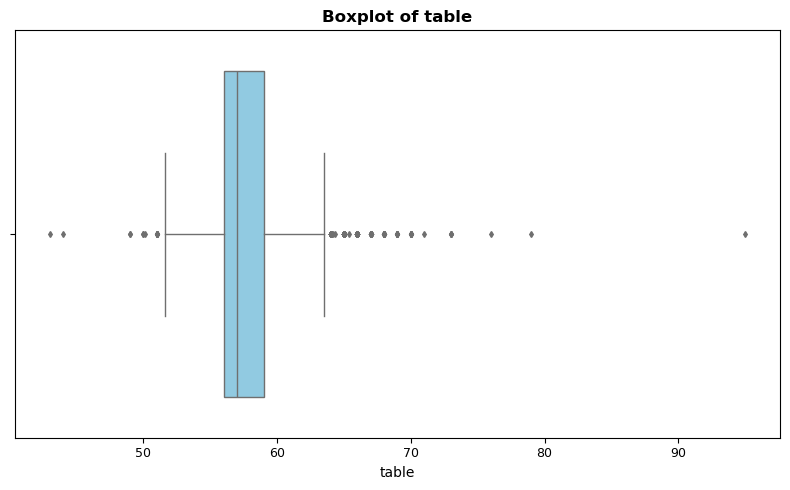

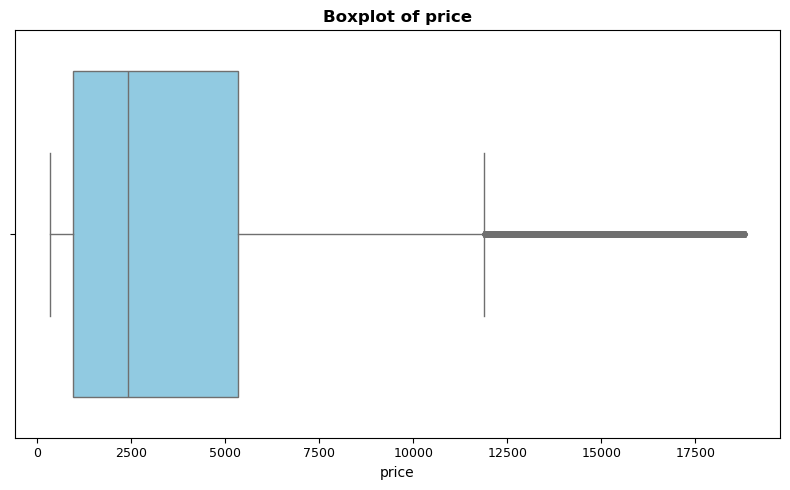

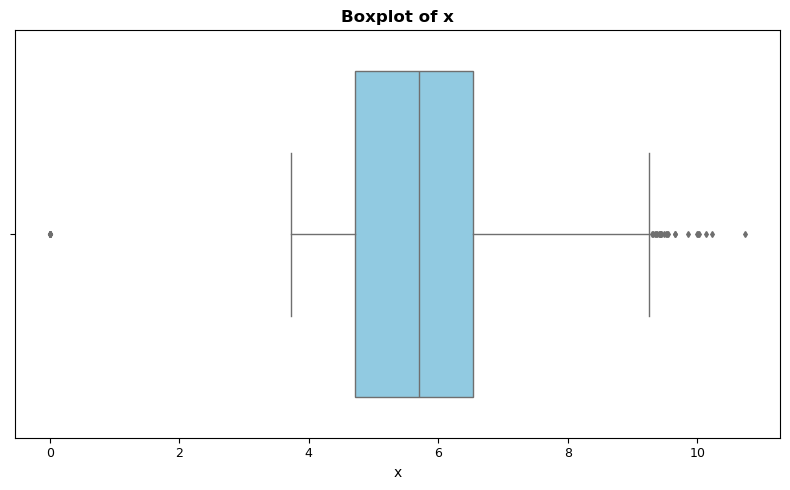

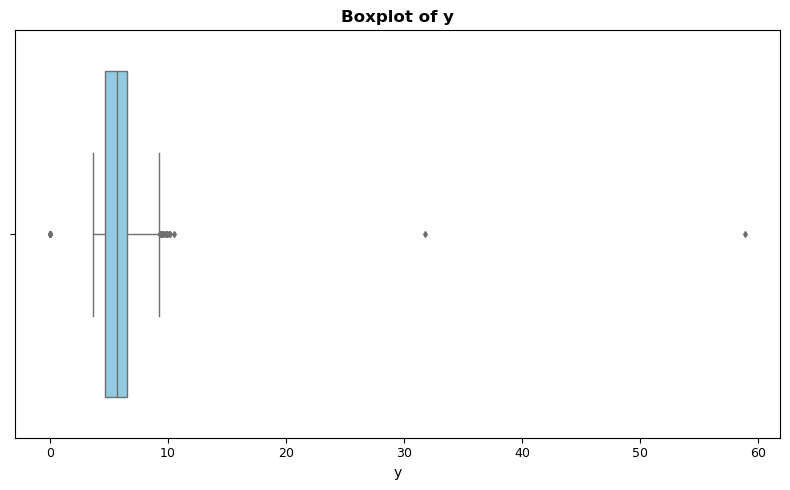

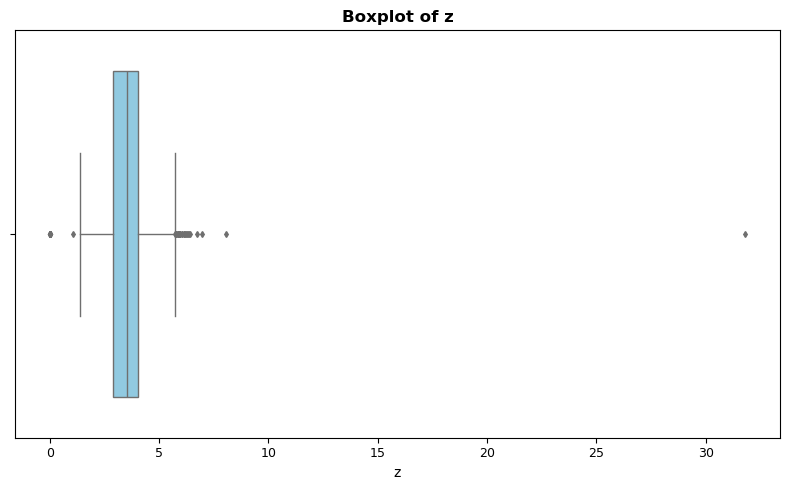

In [3]:

numerical_columns = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
categorical_columns = ['cut', 'color', 'clarity']

plt.figure(figsize=(8, 6))
for col in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}', fontsize=16)
    plt.xlabel(col)
    plt.ylabel('count')
    plt.show()
    
for col in categorical_columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(y=col, data=df)
    plt.title(f'Distribution of {col}', fontsize=16)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

plt.figure(figsize=(8, 6))
for col in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col], color="skyblue", fliersize=3, linewidth=1, saturation=0.8)
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.xticks(fontsize=9)
    plt.tight_layout()
    plt.show()

## Preprocessing 

In [4]:
df= df.drop(columns=['Unnamed: 0'], axis = 1)
df.describe()
df.isna().sum()

df.loc[df.duplicated()]
duplicates = df.duplicated()
df = df.drop_duplicates()
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### standard scale for numerical data

In [ ]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns
ordinal_features = ['cut','clarity','color']

scaler = StandardScaler()
df_numeric_transformed = scaler.fit_transform(df[numeric_features])

### categorical data: onehot or label encoding

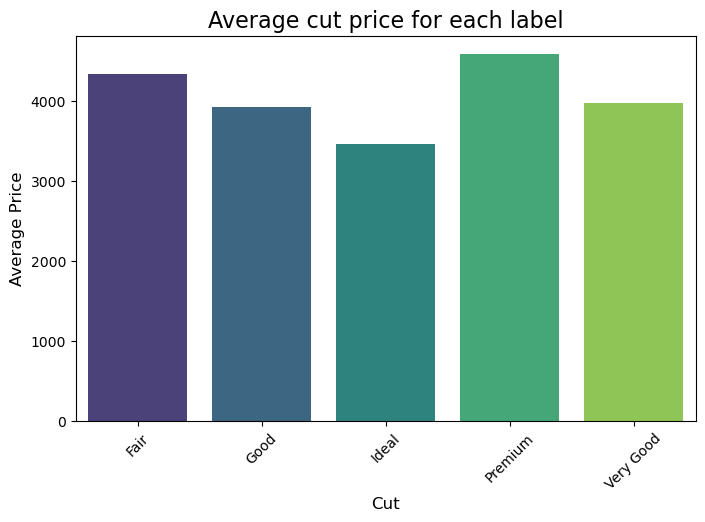

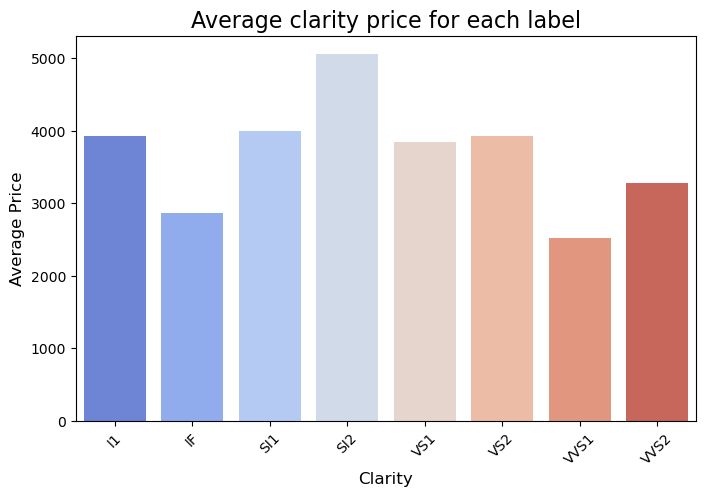

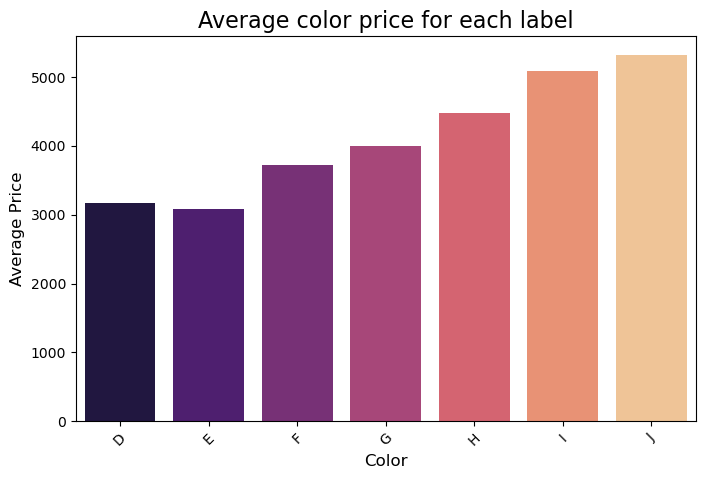

In [6]:

average_price_per_cut = df.groupby('cut')['price'].mean()
plt.figure(figsize=(8, 5))
sns.barplot(x=average_price_per_cut.index, y=average_price_per_cut.values, palette='viridis')
plt.title('Average cut price for each label', fontsize=16)
plt.xlabel('Cut', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.xticks(rotation=45)
plt.show()


average_price_per_clarity = df.groupby('clarity')['price'].mean()
plt.figure(figsize=(8, 5))
sns.barplot(x=average_price_per_clarity.index, y=average_price_per_clarity.values, palette='coolwarm')
plt.title('Average clarity price for each label', fontsize=16)
plt.xlabel('Clarity', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.xticks(rotation=45)
plt.show()


average_price_per_color = df.groupby('color')['price'].mean()
plt.figure(figsize=(8, 5))
sns.barplot(x=average_price_per_color.index, y=average_price_per_color.values, palette='magma')
plt.title('Average color price for each label', fontsize=16)
plt.xlabel('Color', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### label encoding

In [7]:

ordinal_encoder = OrdinalEncoder()
df_ordinal_transformed = ordinal_encoder.fit_transform(df[ordinal_features])


X_transformed = np.hstack((df_numeric_transformed, df_ordinal_transformed))

all_feature_names = (
    list(numeric_features) +
    ordinal_features 
)

df_transformed = pd.DataFrame(X_transformed, columns=all_feature_names)

print(df_transformed.head())

      carat     depth     table     price         x         y         z  cut  \
0 -1.199402 -0.173495 -1.100486 -0.904462 -1.589399 -1.537553 -1.572574  2.0   
1 -1.241651 -1.362393  1.585691 -0.904462 -1.642938 -1.660231 -1.742780  3.0   
2 -1.199402 -3.390512  3.376475 -0.904211 -1.500168 -1.458689 -1.742780  1.0   
3 -1.072656  0.455922  0.242603 -0.902456 -1.366321 -1.318485 -1.288899  3.0   
4 -1.030407  1.085338  0.242603 -0.902205 -1.241397 -1.213332 -1.118694  1.0   

   clarity  color  
0      3.0    1.0  
1      2.0    1.0  
2      4.0    1.0  
3      5.0    5.0  
4      3.0    6.0  


## correlation matrix

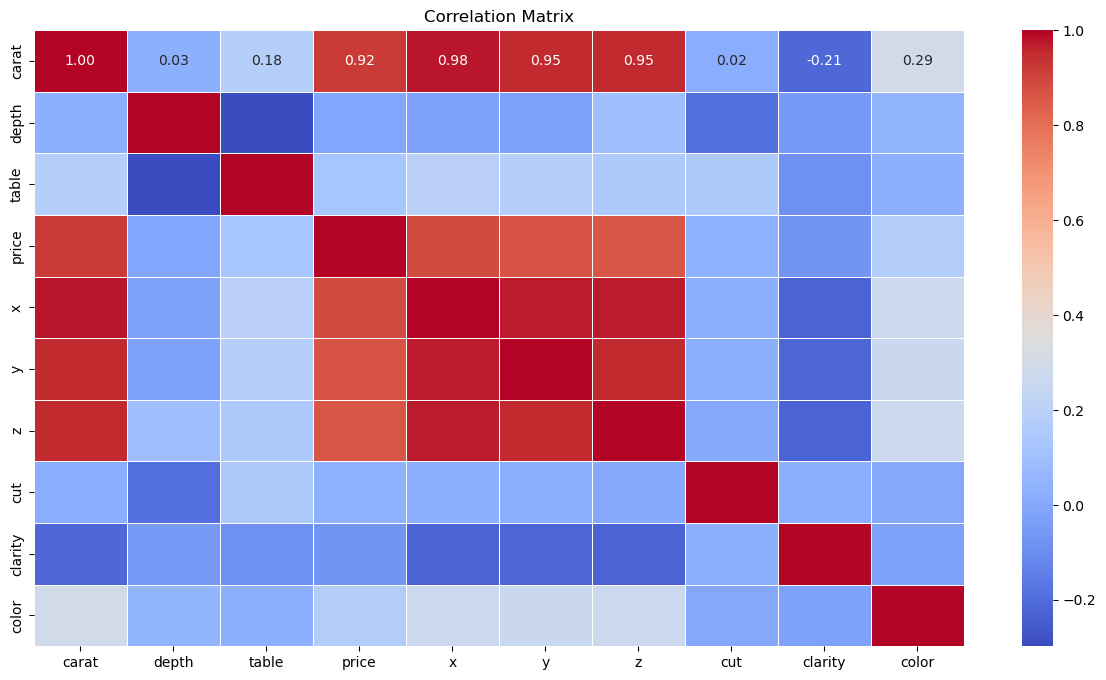

In [8]:
correlation_matrix = df_transformed.corr()
plt.figure(figsize=(15, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

## Correlation with Target feature (price)

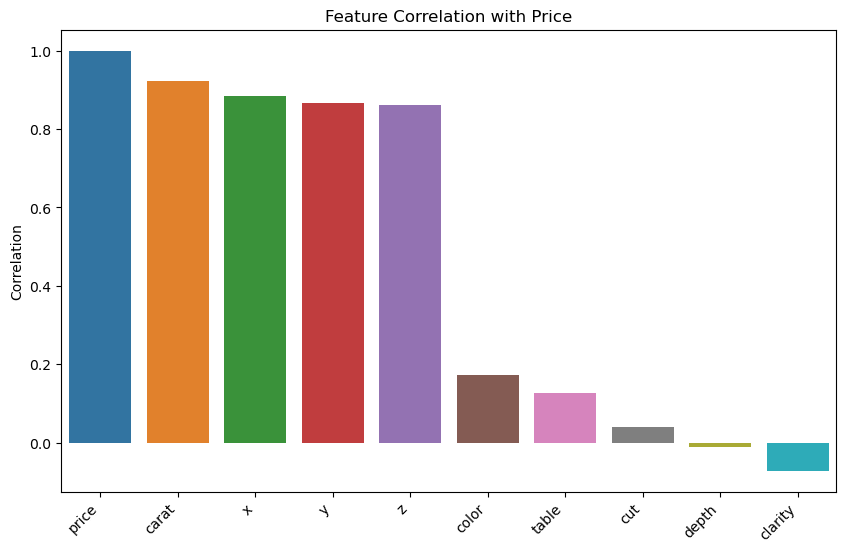

price      1.000000
carat      0.921548
x          0.884504
y          0.865395
z          0.861208
color      0.171825
table      0.126566
cut        0.040196
depth     -0.011048
clarity   -0.071218
Name: price, dtype: float64


In [9]:

price_correlation = correlation_matrix['price'].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=price_correlation.index, y=price_correlation.values)
plt.xticks(rotation=45, ha='right')
plt.title('Feature Correlation with Price')
plt.ylabel('Correlation')
plt.show()

print(price_correlation)

## Regression tree

In [11]:
x = df_transformed.drop(columns=['price'])
y = df_transformed['price']

SEED = 11
random.seed(SEED) 
np.random.seed(SEED)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3,
                                                    random_state=SEED)

tree_model = DecisionTreeRegressor(random_state=SEED)
tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)
y_train_pred = tree_model.predict(X_train)



mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)


print("Model Evaluation Metrics:")
print("Mean Squared Error (MSE): ", mse)
print("Mean Absolute Error (MAE): ", mae)
print("R-squared (R2): ", r2)

print("\nModel Evaluation Metrics for Training Set:")
print("Mean Squared Error (MSE): ", train_mse)
print("Mean Absolute Error (MAE): ", train_mae)
print("R-squared (R2): ", train_r2)


Model Evaluation Metrics:
Mean Squared Error (MSE):  0.03455496150051224
Mean Absolute Error (MAE):  0.09204369778205176
R-squared (R2):  0.9655425766036805

Model Evaluation Metrics for Training Set:
Mean Squared Error (MSE):  4.920210508922369e-06
Mean Absolute Error (MAE):  0.0001071777786166356
R-squared (R2):  0.999995073405978


## Random forest regression

In [12]:

rf_model = RandomForestRegressor(random_state=SEED, n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
y_train_pred = rf_model.predict(X_train)


mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)


print("Mean Squared Error (MSE): ", mse)
print("Mean Absolute Error (MAE): ", mae)
print("R-squared (R2): ", r2)

print("\nModel Evaluation Metrics for Training Set:")
print("Mean Squared Error (MSE): ", train_mse)
print("Mean Absolute Error (MAE): ", train_mae)
print("R-squared (R2): ", train_r2)

Mean Squared Error (MSE):  0.018794905845671936
Mean Absolute Error (MAE):  0.06864311079396893
R-squared (R2):  0.9812581464340894

Model Evaluation Metrics for Training Set:
Mean Squared Error (MSE):  0.002771952766952009
Mean Absolute Error (MAE):  0.025672660871066195
R-squared (R2):  0.997224450883562
